Import libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load Datasets

In [11]:
digits = load_digits()
cancer = load_breast_cancer()

X_digits, y_digits = digits.data, digits.target
X_cancer, y_cancer = cancer.data, cancer.target

print("MNIST Shape:", X_digits.shape)
print("Cancer Shape:", X_cancer.shape)

print("Cancer Features:", cancer.feature_names[:5])
print("Sample Digit Target:", y_digits[:10])

MNIST Shape: (1797, 64)
Cancer Shape: (569, 30)
Cancer Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Sample Digit Target: [0 1 2 3 4 5 6 7 8 9]


Train-Test Split

In [12]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=42)

Logistic Regression

In [13]:
lr_cancer = LogisticRegression(max_iter=5000)
lr_cancer.fit(X_train_c, y_train_c)

y_pred_lr_c = lr_cancer.predict(X_test_c)

print("\nLogistic Regression (Cancer)")
print("Accuracy:", accuracy_score(y_test_c, y_pred_lr_c))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_lr_c))



Logistic Regression (Cancer)
Accuracy: 0.9766081871345029
Confusion Matrix:
 [[ 61   2]
 [  2 106]]


F1 Score

In [14]:
print("\nClassification Report (Cancer):")
print(classification_report(y_test_c, y_pred_lr_c))


Classification Report (Cancer):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



Logistic Regression (MNIST)

In [15]:
lr_digits = LogisticRegression(max_iter=5000)
lr_digits.fit(X_train_d, y_train_d)

y_pred_lr_d = lr_digits.predict(X_test_d)

print("\nLogistic Regression (Digits)")
print("Accuracy:", accuracy_score(y_test_d, y_pred_lr_d))


Logistic Regression (Digits)
Accuracy: 0.9685185185185186


SVM (BINARY)

In [16]:
svm_cancer = SVC()
svm_cancer.fit(X_train_c, y_train_c)

y_pred_svm_c = svm_cancer.predict(X_test_c)

print("\nSVM (Cancer)")
print("Accuracy:", accuracy_score(y_test_c, y_pred_svm_c))



SVM (Cancer)
Accuracy: 0.935672514619883


SVM(MNIST)

In [17]:
svm_digits = SVC()
svm_digits.fit(X_train_d, y_train_d)

y_pred_svm_d = svm_digits.predict(X_test_d)

print("\nSVM (Digits)")
print("Accuracy:", accuracy_score(y_test_d, y_pred_svm_d))


SVM (Digits)
Accuracy: 0.987037037037037


Confusion Matrix Plot

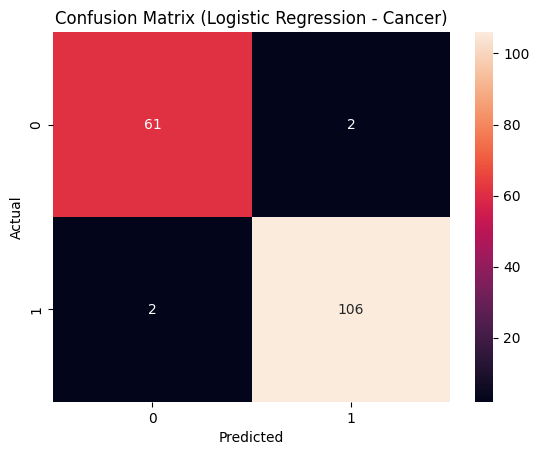

In [18]:
cm = confusion_matrix(y_test_c, y_pred_lr_c)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression - Cancer)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Comparison Print

In [19]:
print("\n--- Model Comparison ---")
print("LR Cancer Accuracy:", accuracy_score(y_test_c, y_pred_lr_c))
print("SVM Cancer Accuracy:", accuracy_score(y_test_c, y_pred_svm_c))
print("LR Digits Accuracy:", accuracy_score(y_test_d, y_pred_lr_d))
print("SVM Digits Accuracy:", accuracy_score(y_test_d, y_pred_svm_d))


--- Model Comparison ---
LR Cancer Accuracy: 0.9766081871345029
SVM Cancer Accuracy: 0.935672514619883
LR Digits Accuracy: 0.9685185185185186
SVM Digits Accuracy: 0.987037037037037


CONCLUSION - In this experiment, we implemented both binary and multiclass classification using Logistic Regression and SVM. The models were evaluated using accuracy, confusion matrix, and F1-score. It was observed that SVM generally provides better performance for complex data but takes more computation time, while Logistic Regression is faster and simpler. Overall, this experiment helped in understanding model comparison and the importance of proper evaluation metrics in classification tasks.